
Evaluating: F(x) = x^5 + x - 1


,Iteration,x_i (Guess),f(x_i),f'(x_i),Approx Error
0,1,1.000000,1.000000e+00,6.000000,1.666667e-01
1,2,0.833333,2.352109e-01,3.411265,6.895122e-02
2,3,0.764382,2.532928e-02,2.706916,9.357248e-03
3,4,0.755025,3.862882e-04,2.624857,1.471655e-04
4,5,0.754878,9.319893e-08,2.623590,3.552343e-08


Final Approximate Root: 0.754878


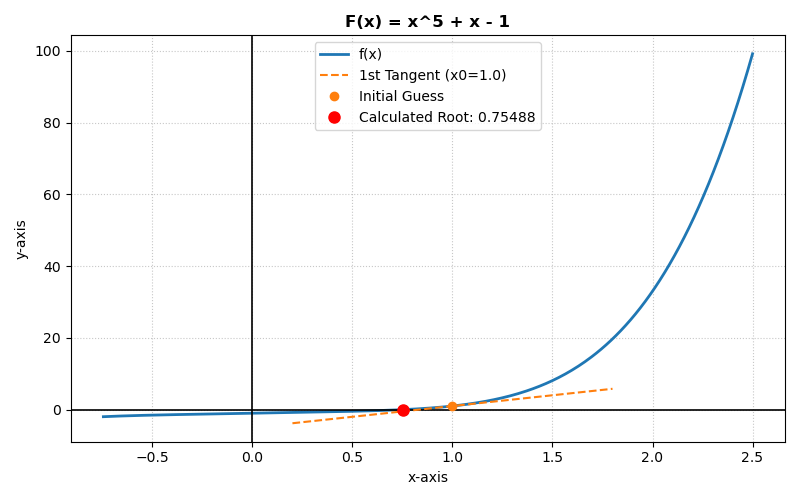


Evaluating: F(x) = x^5 + 5x^3 - 4x + 1


,Iteration,x_i (Guess),f(x_i),f'(x_i),Approx Error
0,1,0.500000,-3.437500e-01,0.062500,5.500000e+00
1,2,6.000000,8.833000e+03,7016.000000,1.258979e+00
2,3,4.741021,2.910158e+03,2859.298729,1.017787e+00
3,4,3.723233,9.596591e+02,1164.776736,8.238996e-01
4,5,2.899334,3.161395e+02,475.407573,6.649863e-01
5,6,2.234347,1.035223e+02,195.500290,5.295250e-01
6,7,1.704822,3.335644e+01,81.832635,4.076179e-01
7,8,1.297204,1.039864e+01,35.399144,2.937541e-01
8,9,1.003450,3.055502e+00,16.173050,1.889256e-01
9,10,0.814525,8.024118e-01,8.152590,9.842416e-02


Final Approximate Root: 0.680610


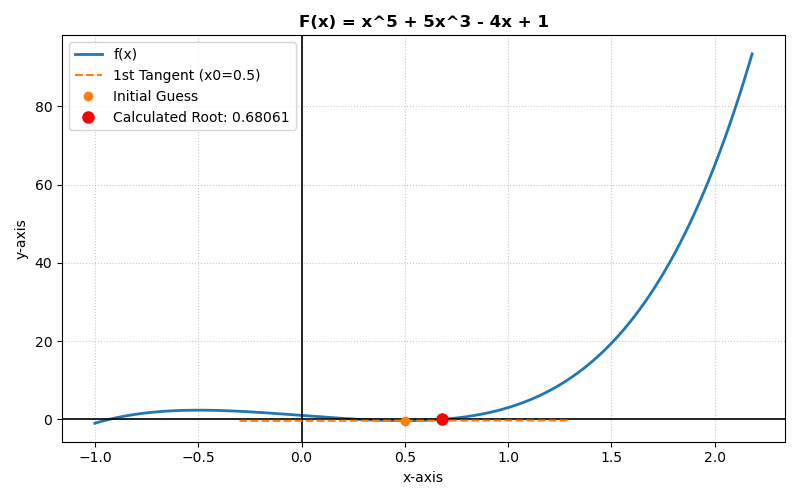


Evaluating: F(x) = x^5 + 2x^4 - x - 3


,Iteration,x_i (Guess),f(x_i),f'(x_i),Approx Error
0,1,1.000000,-1.000000e+00,12.000000,8.333333e-02
1,2,1.083333,1.635360e-01,16.058111,1.018401e-02
2,3,1.073149,2.757805e-03,15.518617,1.777094e-04
3,4,1.072972,8.266279e-07,15.509315,5.329880e-08


Final Approximate Root: 1.072972


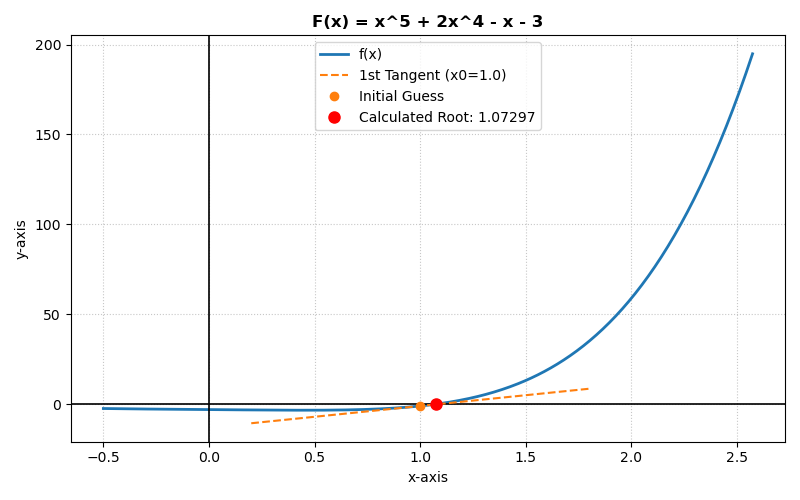


Evaluating: F(x) = x^5 - 10


,Iteration,x_i (Guess),f(x_i),f'(x_i),Approx Error
0,1,1.500000,-2.406250e+00,25.312500,9.506173e-02
1,2,1.595062,3.249385e-01,32.365326,1.003971e-02
2,3,1.585022,4.064820e-03,31.558126,1.288042e-04
3,4,1.584893,6.605883e-07,31.547869,2.093924e-08


Final Approximate Root: 1.584893


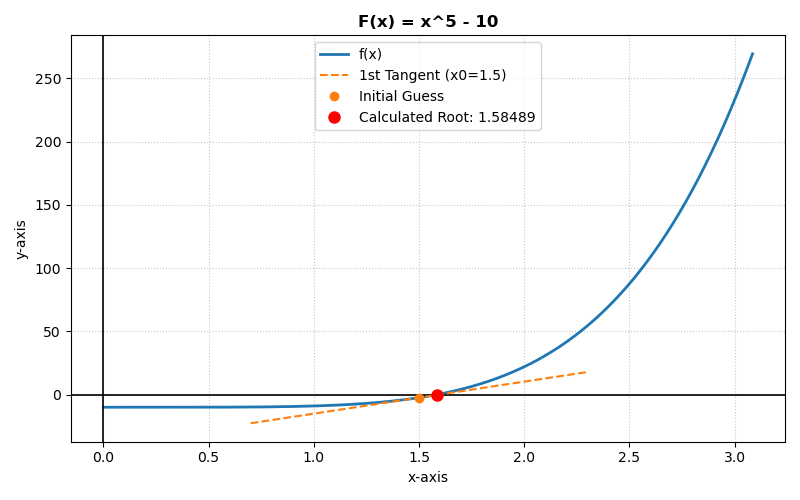


Evaluating: F(x) = x^5 + 2x^2 + x - 0.5


,Iteration,x_i (Guess),f(x_i),f'(x_i),Approx Error
0,1,0.500000,0.531250,3.312500,1.603774e-01
1,2,0.339623,0.074828,2.425011,3.085681e-02
2,3,0.308766,0.002245,2.280508,9.843831e-04
3,4,0.307781,0.000002,2.275994,9.764331e-07


Final Approximate Root: 0.307780


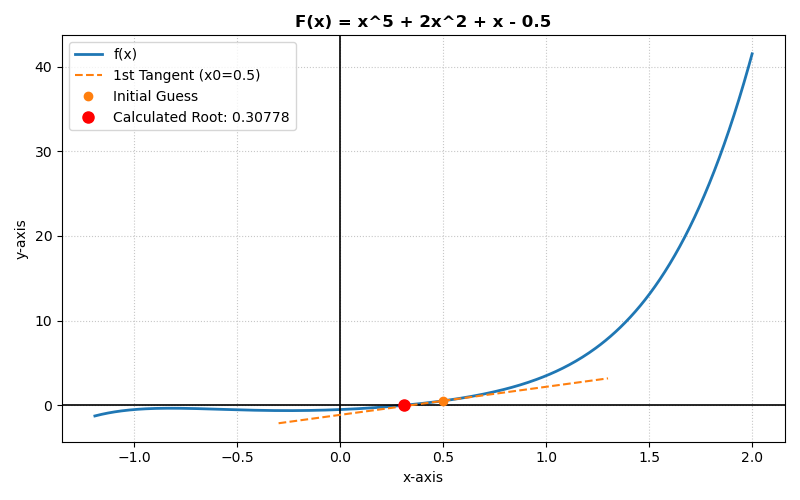

In [3]:
# Enable interactive plots in Jupyter for zooming and panning
%matplotlib widget

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

# ==========================================
# TASK 1: Function and Derivative Definition
# ==========================================
# We define the 5 quintic test functions and their analytical derivatives

# Function 1
def f1(x):  return x**5 + x - 1
def df1(x): return 5*x**4 + 1

# Function 2
def f2(x):  return x**5 + 5*x**3 - 4*x + 1
def df2(x): return 5*x**4 + 15*x**2 - 4

# Function 3
def f3(x):  return x**5 + 2*x**4 - x - 3
def df3(x): return 5*x**4 + 8*x**3 - 1

# Function 4
def f4(x):  return x**5 - 10
def df4(x): return 5*x**4

# Function 5
def f5(x):  return x**5 + 2*x**2 + x - 0.5
def df5(x): return 5*x**4 + 4*x + 1


# ==========================================
# TASK 2: Implementation of the Algorithm
# ==========================================
# Note: I added 'f' and 'df' to the parameters so the function is truly generalized.
def newton_raphson(f, df, x0, tolerance=1e-6, max_iter=50):
    iteration_data = []
    x = x0
    
    for i in range(max_iter):
        fx = f(x)
        dfx = df(x)
        
        # Safety Check: Prevent Division by Zero
        if abs(dfx) < 1e-12:
            print(f"🛑 ERROR: Derivative close to zero at x = {x:.6f}. Stopping to prevent division by zero.")
            break
            
        # Newton-Raphson Formula
        x_new = x - (fx / dfx)
        approx_error = abs(x_new - x)
        
        # Store data for tabulation
        iteration_data.append({
            'Iteration': i + 1,
            'x_i (Guess)': x,
            'f(x_i)': fx,
            "f'(x_i)": dfx,
            'Approx Error': approx_error
        })
        
        x = x_new
        
        # Convergence Check
        if approx_error < tolerance:
            break
            
    # Create formatted table
    df_results = pd.DataFrame(iteration_data)
    return x, df_results


# ==========================================
# TASK 3: Visualization & Execution
# ==========================================
def visualize_nr(f, df, x0, root, title):
    """Generates an interactive plot for the function, root, and first tangent line."""
    # Define a dynamic range based on the root and initial guess
    x_min = min(x0, root) - 1.5
    x_max = max(x0, root) + 1.5
    x_vals = np.linspace(x_min, x_max, 400)
    y_vals = f(x_vals)
    
    # Create the figure
    fig, ax = plt.subplots(figsize=(8, 5))
    
    # Plot the main function
    ax.plot(x_vals, y_vals, label='f(x)', color='#1f77b4', linewidth=2)
    
    # X and Y axis lines
    ax.axhline(0, color='black', linewidth=1.2)
    ax.axvline(0, color='black', linewidth=1.2)
    
    # Plot the first tangent line (Optional Challenge)
    fx0 = f(x0)
    dfx0 = df(x0)
    # Equation of tangent line: y = m(x - x0) + y0
    x_tan = np.linspace(x0 - 0.8, x0 + 0.8, 100)
    y_tan = dfx0 * (x_tan - x0) + fx0
    
    ax.plot(x_tan, y_tan, '--', color='#ff7f0e', label=f"1st Tangent (x0={x0})")
    ax.plot(x0, fx0, 'o', color='#ff7f0e', markersize=6, label="Initial Guess")
    
    # Mark the final root
    if root is not None:
        ax.plot(root, 0, 'ro', markersize=8, label=f"Calculated Root: {root:.5f}")
    
    # Graph formatting
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('x-axis')
    ax.set_ylabel('y-axis')
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

# --- Run the tests for all Quintic Functions ---

# List containing (function, derivative, string_name, initial_guess)
test_cases = [
    (f1, df1, "F(x) = x^5 + x - 1", 1.0),
    (f2, df2, "F(x) = x^5 + 5x^3 - 4x + 1", 0.5),
    (f3, df3, "F(x) = x^5 + 2x^4 - x - 3", 1.0),
    (f4, df4, "F(x) = x^5 - 10", 1.5),
    (f5, df5, "F(x) = x^5 + 2x^2 + x - 0.5", 0.5)
]

for func, deriv, name, initial_guess in test_cases:
    print(f"\n" + "="*50)
    print(f"Evaluating: {name}")
    print("="*50)
    
    # Run algorithm
    root, df_table = newton_raphson(func, deriv, initial_guess)
    
    # Print formatted table
    display(df_table)
    print(f"Final Approximate Root: {root:.6f}")
    
    # Visualize in separate graphs
    visualize_nr(func, deriv, initial_guess, root, title=name)